In [1]:
# Q2 – CUSTOMER SEGMENTATION
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Data Loading

Customer dataset contains behavioral and spending features used for segmentation.

In [2]:
df = pd.read_csv(r"D:\bits course\assignment 4\q2_customers.csv")
df.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1


### Dataset Overview

- Total records: 500  
- Features: age, spend, visits, basket size, etc.  
- No missing values

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   age                       500 non-null    int64
 1   annual_spend              500 non-null    int64
 2   visits_per_month          500 non-null    int64
 3   basket_size               500 non-null    int64
 4   days_since_last_visit     500 non-null    int64
 5   num_categories_purchased  500 non-null    int64
dtypes: int64(6)
memory usage: 23.6 KB


In [4]:
df.describe()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
count,500.00000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,40.45200,48856.948000,8.414000,2682.286000,49.466000,4.658000
std,14.42664,32856.795353,5.324595,2274.957339,49.699143,2.438222
min,18.00000,5038.000000,1.000000,212.000000,0.000000,1.000000
25%,28.00000,19213.250000,4.000000,727.750000,12.000000,3.000000
50%,41.00000,44257.000000,8.000000,2051.500000,33.000000,4.000000
75%,50.00000,75373.000000,12.000000,4223.750000,61.250000,6.000000
max,69.00000,119757.000000,19.000000,7981.000000,179.000000,9.000000


In [5]:
df.shape

(500, 6)

In [6]:
df.columns

Index(['age', 'annual_spend', 'visits_per_month', 'basket_size',
       'days_since_last_visit', 'num_categories_purchased'],
      dtype='str')

In [7]:
isnull = df.isnull().sum()
print(isnull)

age                         0
annual_spend                0
visits_per_month            0
basket_size                 0
days_since_last_visit       0
num_categories_purchased    0
dtype: int64


### Exploratory Data Analysis

- Histograms show distribution of features  
- Heatmap shows strong correlations  
- Pairplot shows cluster patterns  

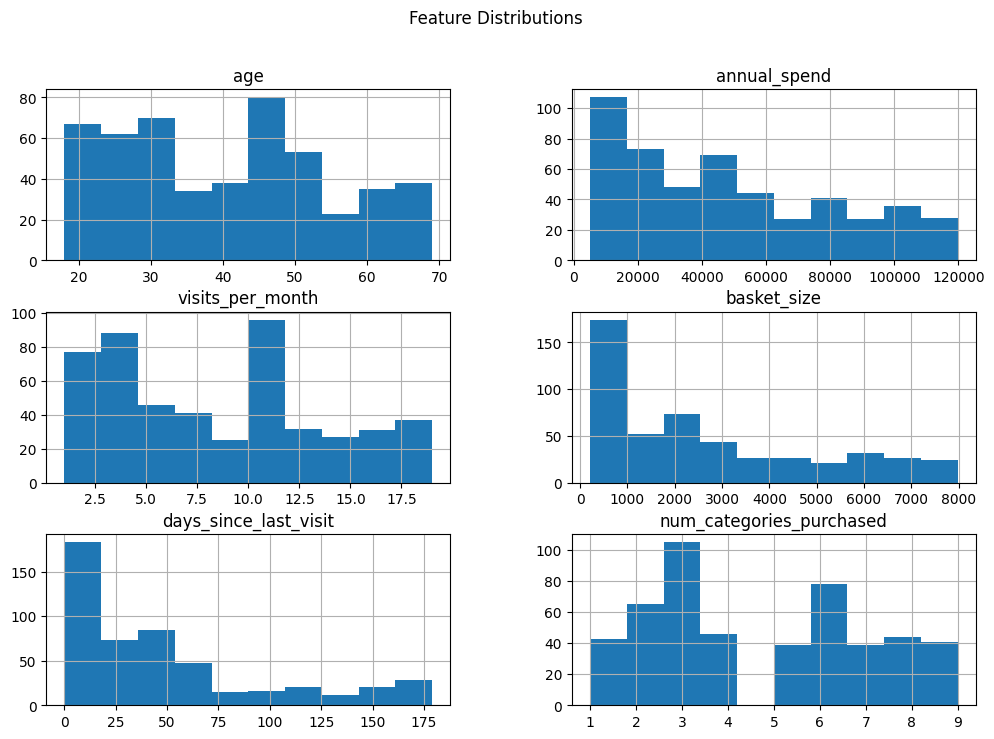

In [8]:
df.hist(figsize=(12,8))
plt.suptitle("Feature Distributions")
plt.show()

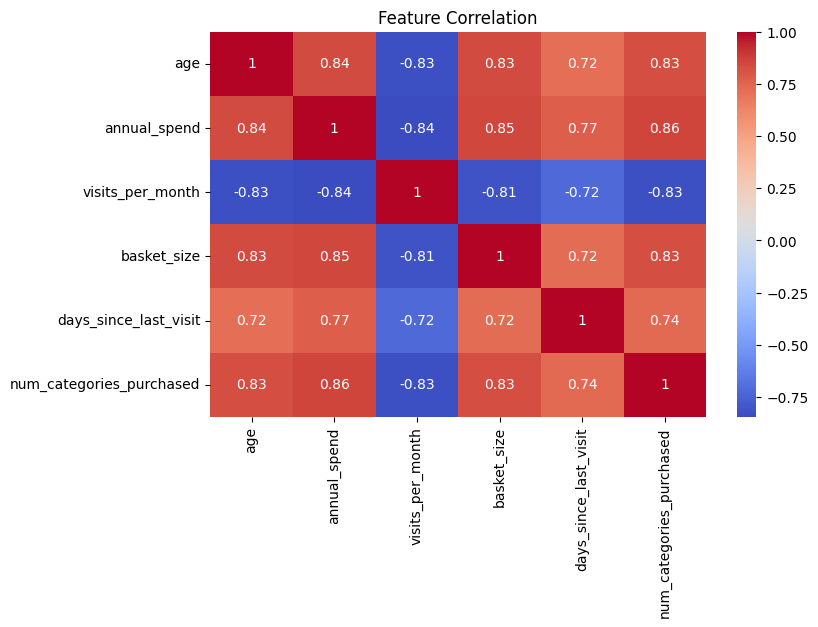

In [9]:
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

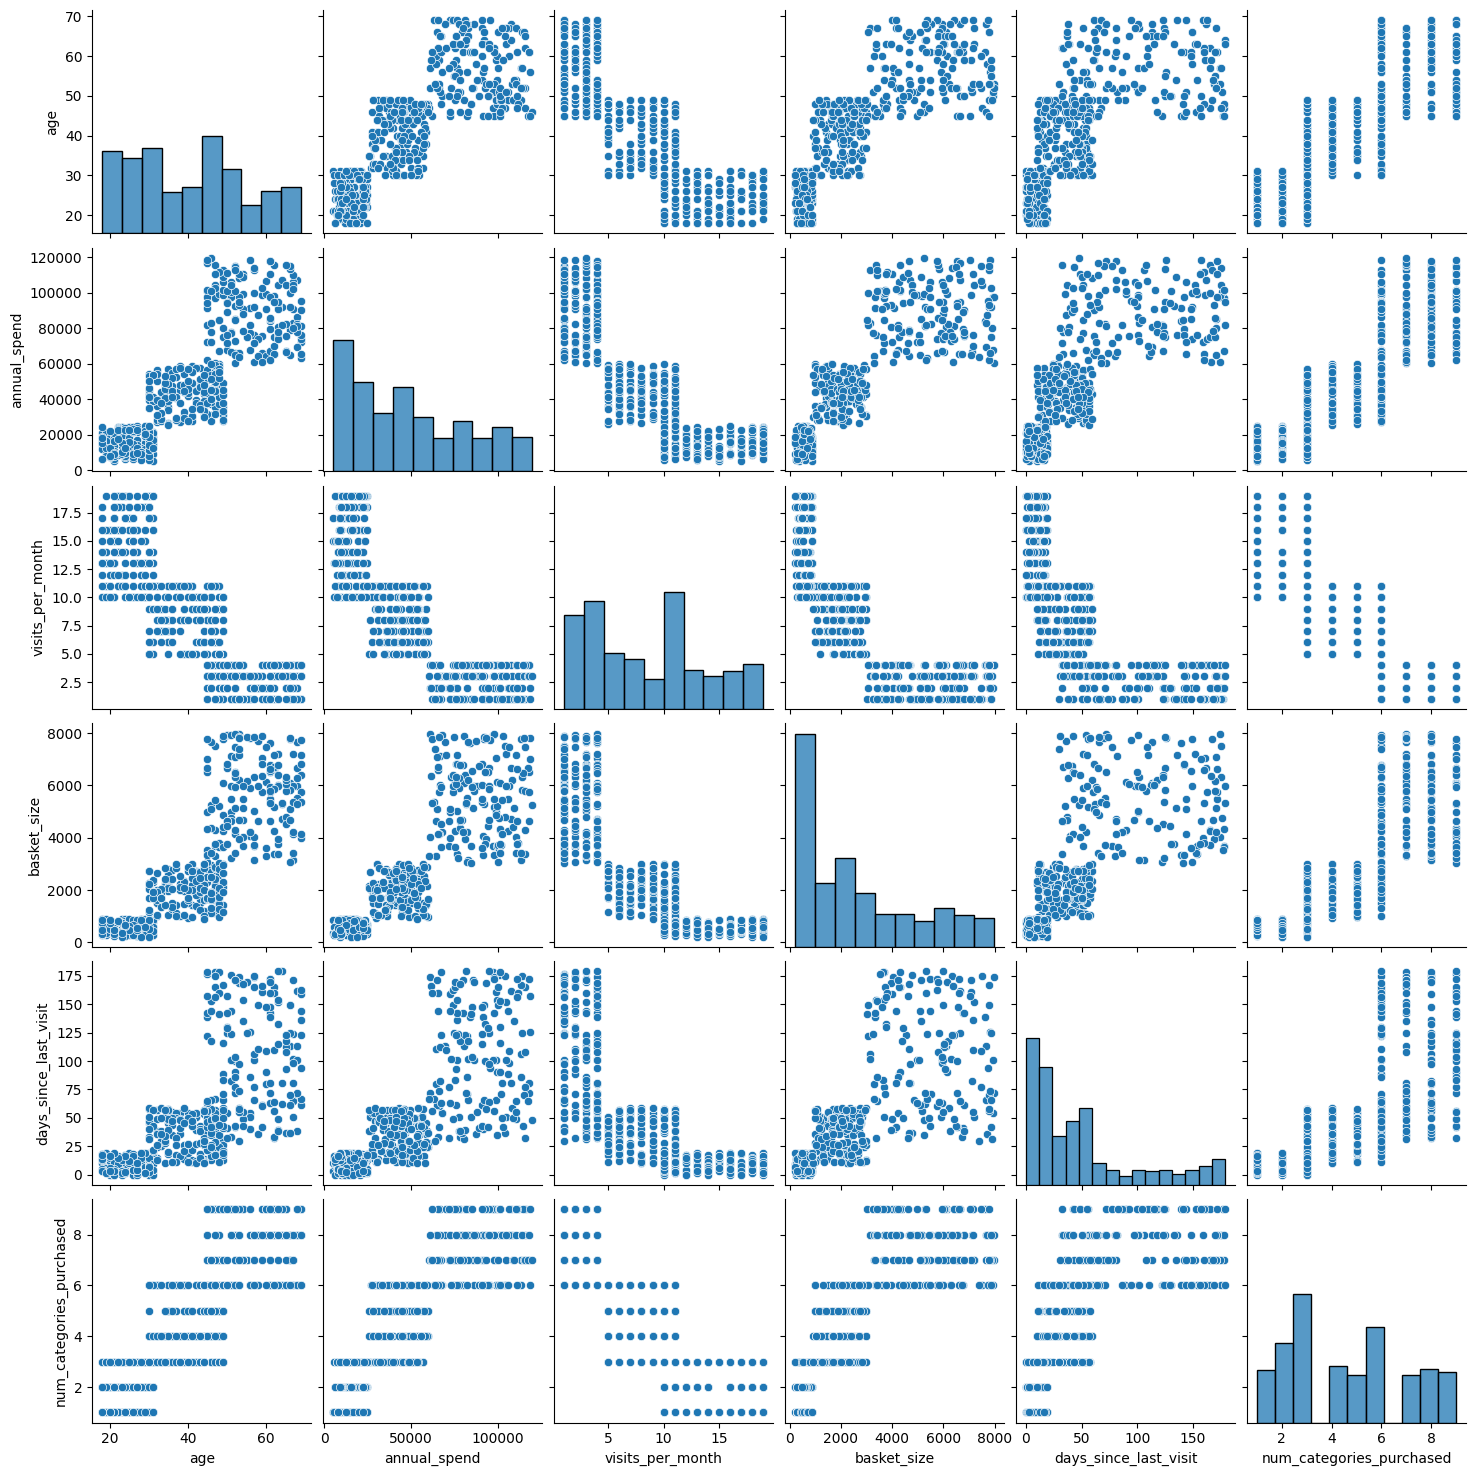

In [10]:
sns.pairplot(df)
plt.show()

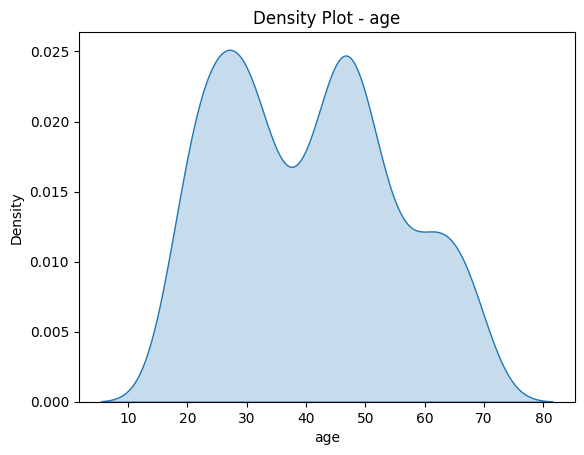

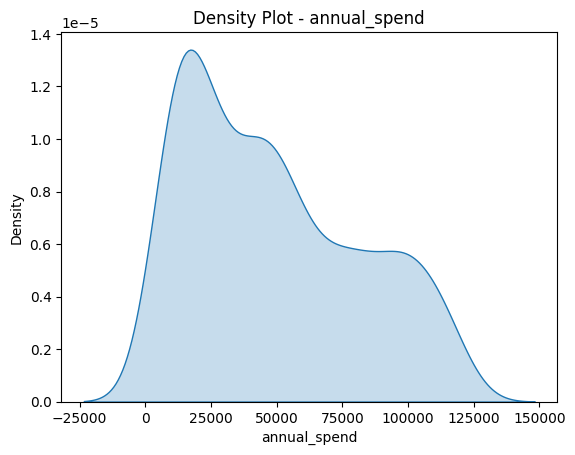

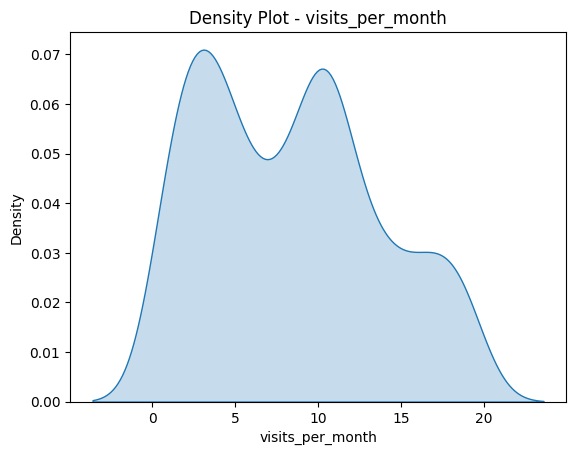

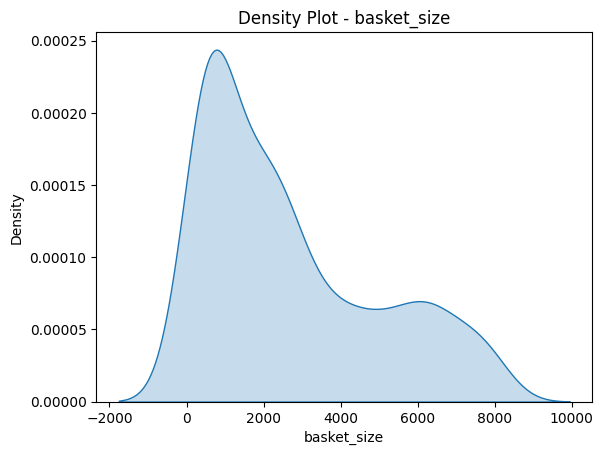

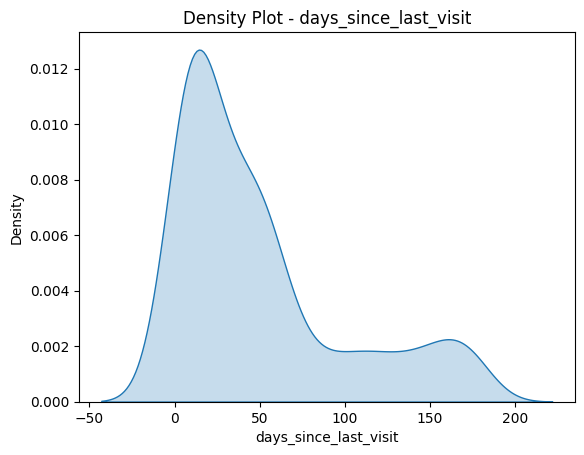

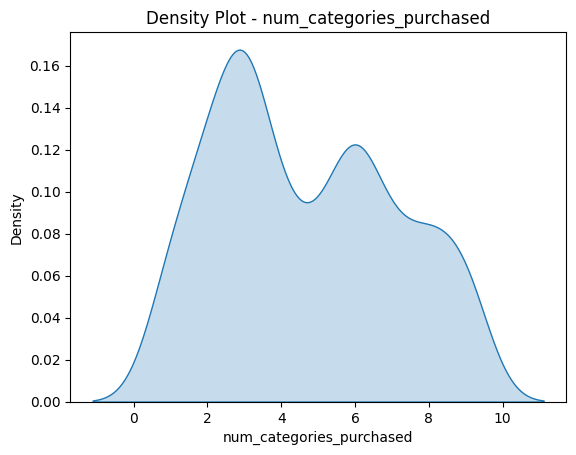

In [11]:
for col in df.columns:
    sns.kdeplot(df[col], fill=True)
    plt.title(f"Density Plot - {col}")
    plt.show()

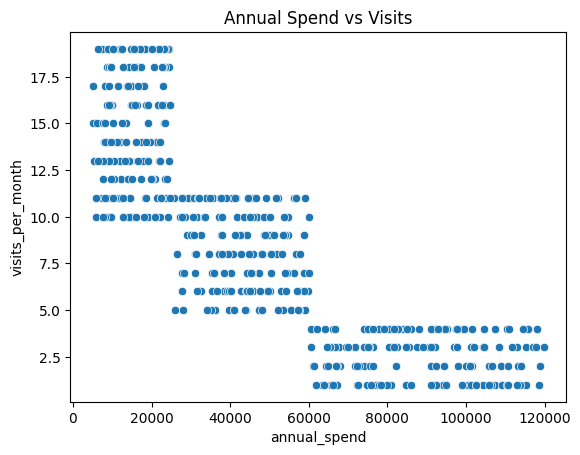

In [12]:
sns.scatterplot(x='annual_spend', y='visits_per_month', data=df)
plt.title("Annual Spend vs Visits")
plt.show()

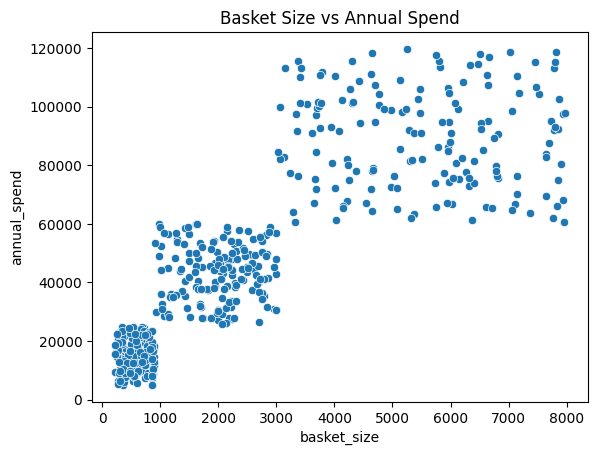

In [13]:
sns.scatterplot(x='basket_size', y='annual_spend', data=df)
plt.title("Basket Size vs Annual Spend")
plt.show()

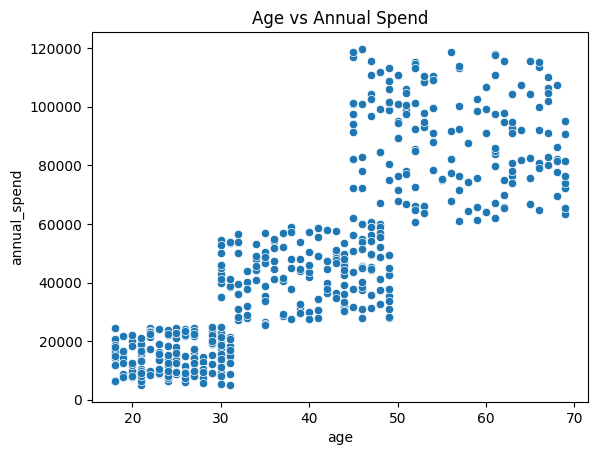

In [14]:
sns.scatterplot(x='age', y='annual_spend', data=df)
plt.title("Age vs Annual Spend")
plt.show()

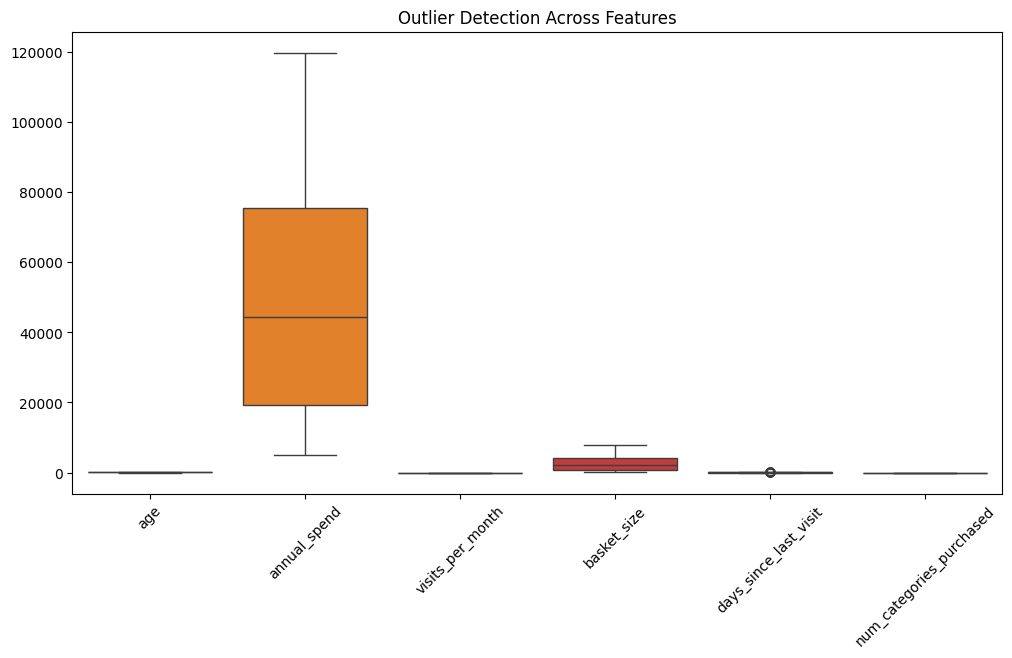

In [16]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.title("Outlier Detection Across Features")
plt.xticks(rotation=45)
plt.show()

### Feature Scaling

- StandardScaler applied to normalize data  
- Required for clustering algorithms

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

### Optimal Cluster Selection

- Elbow method used to find optimal K  
- WCSS decreases with increasing clusters  

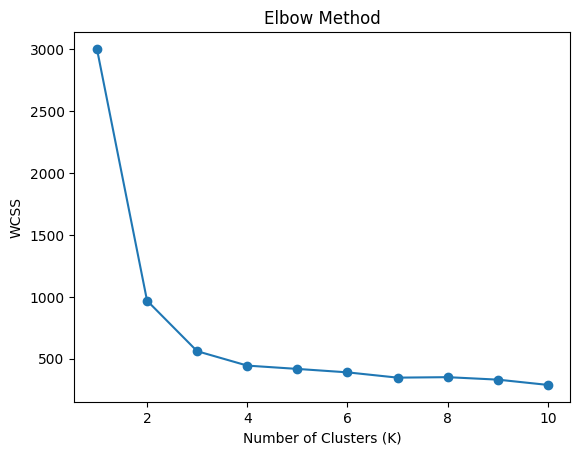

In [18]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

### Cluster Validation

- Silhouette score used to evaluate clustering quality  
- Best score observed around K = 2–4

In [21]:
from sklearn.metrics import silhouette_score

for k in range(1, 11):
    model = KMeans(n_clusters=k, random_state=42)
    labels = model.fit_predict(X_scaled)
    if k > 1:
        print("K =", k, "Score =", silhouette_score(X_scaled, labels))

K = 2 Score = 0.5820670815334009
K = 3 Score = 0.5081806621994936
K = 4 Score = 0.4551920696891059
K = 5 Score = 0.4275629165662411
K = 6 Score = 0.3236653555577831
K = 7 Score = 0.2623345566113047
K = 8 Score = 0.29333755729269173
K = 9 Score = 0.2904937258011505
K = 10 Score = 0.2531322047407239


### K-Means Clustering

- K = 4 selected  
- Customers grouped into 4 segments

In [22]:
kmeans = KMeans(n_clusters=4, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

df.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased,cluster
0,30,43075,9,2080,45,6,2
1,19,14496,11,454,8,3,0
2,43,57632,6,2144,16,4,2
3,30,15629,10,801,0,2,0
4,19,14901,16,396,17,1,0


In [27]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

labels = df['cluster']

sil_score = silhouette_score(X_scaled, labels)
db_score = davies_bouldin_score(X_scaled, labels)
ch_score = calinski_harabasz_score(X_scaled, labels)

print("Silhouette Score:", sil_score)
print("Davies-Bouldin Score:", db_score)
print("Calinski-Harabasz Score:", ch_score)

Silhouette Score: 0.4551920696891059
Davies-Bouldin Score: 1.0405704000254319
Calinski-Harabasz Score: 949.2422939114545


In [23]:
centroids = pd.DataFrame(kmeans.cluster_centers_, columns=df.columns[:-1])
centroids

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,-1.094595,-1.036122,1.114284,-0.934278,-0.813494,-1.045346
1,1.157501,1.246698,-1.118685,1.171838,1.965682,1.176784
2,-0.004449,-0.168055,-0.041370,-0.290670,-0.287579,-0.095968
3,1.107231,1.224585,-1.094820,1.333700,0.295887,1.169244


In [24]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_scaled)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.83560354 0.05568764]


In [25]:
loadings = pd.DataFrame(pca.components_, columns=df.columns[:-1])
loadings

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,0.411569,0.42154,-0.410399,0.412012,0.378582,0.414017
1,-0.259432,-0.03327,0.208318,-0.195402,0.911194,-0.140479


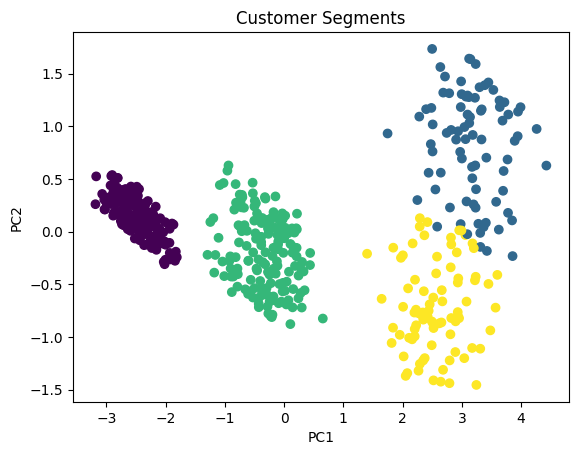

PCA Loadings:
         age  annual_spend  visits_per_month  basket_size  \
0  0.411569       0.42154         -0.410399     0.412012   
1 -0.259432      -0.03327          0.208318    -0.195402   

   days_since_last_visit  num_categories_purchased  
0               0.378582                  0.414017  
1               0.911194                 -0.140479  


In [29]:
plt.scatter(pca_data[:,0], pca_data[:,1], c=df['cluster'])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Customer Segments")
plt.show()
print("PCA Loadings:\n", loadings)


In [28]:
scores = []

for k in range(2,10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    
    sil = silhouette_score(X_scaled, labels)
    scores.append((k, sil))

for k, score in scores:
    print(f"K={k}, Silhouette Score={score}")

K=2, Silhouette Score=0.5820670815334009
K=3, Silhouette Score=0.5081806621994936
K=4, Silhouette Score=0.4551920696891059
K=5, Silhouette Score=0.4275629165662411
K=6, Silhouette Score=0.3236653555577831
K=7, Silhouette Score=0.2623345566113047
K=8, Silhouette Score=0.29333755729269173
K=9, Silhouette Score=0.2904937258011505


### Conclusion

- Customers segmented into meaningful groups  
- Helps in targeted marketing strategies  